#### **Combustível: choque do petróleo, repasse e "sangria" da Petrobras (Fase 2)**

**Pergunta.** O petróleo subiu muito — quanto disso chegou ao combustível no Brasil? Se o
repasse foi pequeno, a Petrobras vendeu derivados abaixo da paridade de importação, e a
diferença vezes o volume é uma estimativa do quanto ela **deixou de arrecadar** ("sangria").

**Método.**
- **Camada A (repasse):** elasticidade de Δlog(preço do combustível) a Δlog(Brent em R$), com defasagens.
- **Camada B (paridade/sangria):** paridade de importação a partir de derivados cotados
  (gasolina RBOB `RB=F`, diesel ULSD `HO=F`) × câmbio; gap vs preço doméstico; `sangria = gap × volume`.

**Fontes.** Yahoo Finance (`yfinance`), ANP (preço de distribuição e vendas em m³).

#### **Estrutura do notebook**

1. Cotações internacionais (yfinance).
2. Preço de distribuição da ANP (mensal, nacional).
3. Vendas mensais da ANP (m³ → litros).
4. Base mensal consolidada com tributos.
5. **Camada A** — repasse do petróleo ao combustível (OLS com defasagens).
6. **Camada B** — paridade de importação e gap.
7. Sangria estimada = gap × volume.
8. Resumo e conclusão.

**Hipótese testável.** Se o repasse for incompleto e o gap de paridade positivo em janelas
específicas, há represamento seletivo — sobretudo na gasolina, politicamente sensível.


In [1]:
# Bibliotecas: coleta HTTP (requests), parsing de planilhas/CSV (pandas), álgebra (numpy),
# visualização (matplotlib/seaborn) e descompactação de arquivos (zipfile).
import io, zipfile
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns

# Padrões visuais globais para gráficos legíveis e consistentes.
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
# Cabeçalho de navegador: algumas URLs do gov.br bloqueiam o user-agent padrão.
UA = {"User-Agent": "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36"}

# Fontes ANP: preço médio de distribuição (xlsx) e vendas por segmento (csv, m³).
ANP_DIST = "https://www.gov.br/anp/pt-br/assuntos/precos-e-defesa-da-concorrencia/precos/pdc/mensal/combustiveis-liquidos-brasil.xlsx"
ANP_VENDAS = "https://www.gov.br/anp/pt-br/centrais-de-conteudo/dados-abertos/arquivos/vdpb/vcs/vendas-combustiveis-segmento-m3-2012-2025.csv"

# parâmetro explícito: custo de importação (frete/seguro/despesas), R$/litro
CUSTO_IMPORT = 0.15


sns.set()


#### **1. Cotações internacionais (yfinance)**

**Objetivo.** Obter os preços internacionais que formam o custo de oportunidade da Petrobras:
Brent (petróleo), RBOB (gasolina) e ULSD (diesel), além do câmbio USD/BRL.

**Unidades.** Brent em USD/barril; derivados em USD/galão; câmbio em BRL por USD. A conversão
para R$/litro ocorre na base consolidada.


In [2]:
import yfinance as yf

# Brent (USD/bbl), gasolina RBOB (USD/gal), diesel ULSD (USD/gal), câmbio BRL/USD.
# Série começa em 2020-06 para coincidir com a janela da Fase 1 e a pandemia.
precos = yf.download(["BZ=F", "RB=F", "HO=F", "BRL=X"], start="2020-06-01",
                     auto_adjust=True, progress=False)["Close"]
# ffill cobre feriados em que um mercado negocia e outro não; dropna remove o restante.
precos = precos.ffill().dropna()
print(precos.tail(3))
print("shape:", precos.shape)


Ticker       BRL=X        BZ=F    HO=F    RB=F
Date                                          
2026-09-22  5.1104   99.250000  4.9421  3.4875
2026-09-23  5.0999  103.080002  4.7764  3.5870
2026-09-24  5.1643  106.129997  4.5200  3.2961
shape: (1645, 4)


#### **2. ANP — preço médio de distribuição (nacional, mensal)**

**Fonte.** Planilha oficial da ANP com o preço médio de distribuição por produto e mês.

**Detalhes de parsing.** O cabeçalho real está na linha 9 (`header=8`). Filtramos dois produtos:
`GASOLINA C COMUM` e `ÓLEO DIESEL B S10 - COMUM`, e pivotamos para uma coluna por combustível.

**Ressalva.** Preço de **distribuição** (inclui margem da distribuidora e mistura de
etanol/biodiesel), não o preço na bomba.


In [3]:
# Download e leitura da planilha da ANP (cabeçalho na 9ª linha => header=8).
r = requests.get(ANP_DIST, headers=UA, timeout=60)
dist = pd.read_excel(io.BytesIO(r.content), header=8)
dist.columns = [str(c).strip() for c in dist.columns]
# Normaliza a coluna de mês e descarta linhas sem data válida.
dist["MÊS"] = pd.to_datetime(dist["MÊS"], errors="coerce")
dist = dist.dropna(subset=["MÊS"])
# Mantém apenas os dois combustíveis de interesse e garante tipo numérico no preço.
dist = dist[dist["PRODUTO"].isin(["GASOLINA C COMUM", "ÓLEO DIESEL B S10 - COMUM"])]
dist["PREÇO MÉDIO DE DISTRIBUIÇÃO"] = pd.to_numeric(dist["PREÇO MÉDIO DE DISTRIBUIÇÃO"], errors="coerce")

# Pivota produto x mês -> uma coluna por combustível, com nomes curtos.
dist = (dist.pivot_table(index="MÊS", columns="PRODUTO", values="PREÇO MÉDIO DE DISTRIBUIÇÃO")
             .rename(columns={"GASOLINA C COMUM": "gasolina", "ÓLEO DIESEL B S10 - COMUM": "diesel"}))
print(dist.tail(4))
print("início:", dist.index.min().date(), "| fim:", dist.index.max().date())


PRODUTO     gasolina    diesel
MÊS                           
2026-05-01  5.737429  6.263079
2026-06-01  5.750260  6.167683
2026-07-01  5.640026  6.014158
2026-08-01  5.527726  5.991635
início: 2020-09-01 | fim: 2026-08-01


#### **3. ANP — vendas mensais (m³) → litros**

**Fonte.** Dados abertos de vendas de combustíveis por segmento (CSV, separador `;`).

**Transformações.** Mapeia abreviações de mês (`JAN`…`DEZ`) para número, converte a coluna
`VENDAS` (formato pt-BR com ponto de milhar) para float e converte m³ → litros (×1000).

**Uso.** O volume em litros é a base para monetizar o gap de paridade (sangria).


In [4]:
# Download do CSV de vendas mensais (separador ';', encoding utf-8).
r = requests.get(ANP_VENDAS, headers=UA, timeout=120)
vendas = pd.read_csv(io.BytesIO(r.content), sep=";", encoding="utf-8")

# Converte abreviação do mês em número para montar a data mensal.
MESES = {"JAN":1,"FEV":2,"MAR":3,"ABR":4,"MAI":5,"JUN":6,"JUL":7,"AGO":8,"SET":9,"OUT":10,"NOV":11,"DEZ":12}
vendas["mes"] = vendas["MÊS"].map(MESES)
vendas["data"] = pd.to_datetime(dict(year=vendas["ANO"], month=vendas["mes"], day=1))
# Números no padrão pt-BR: remove ponto de milhar e troca vírgula decimal por ponto.
vendas["VENDAS"] = (vendas["VENDAS"].astype(str)
                    .str.replace(".", "", regex=False).str.replace(",", ".", regex=False).astype(float))

# Agrega vendas por mês e produto; converte m³ -> litros para casar com o preço (R$/L).
vol = (vendas[vendas["PRODUTO"].isin(["GASOLINA C", "ÓLEO DIESEL"])]
       .groupby(["data", "PRODUTO"])["VENDAS"].sum().unstack())
vol = vol.rename(columns={"GASOLINA C": "gasolina_m3", "ÓLEO DIESEL": "diesel_m3"})
vol["gasolina_L"] = vol["gasolina_m3"] * 1000
vol["diesel_L"] = vol["diesel_m3"] * 1000
print(vol[["gasolina_m3", "diesel_m3"]].tail(4))


PRODUTO     gasolina_m3    diesel_m3
data                                
2026-04-01  3940074.400  5655256.783
2026-05-01  3855061.887  5674314.701
2026-06-01  3876406.469  5736689.225
2026-07-01  4002461.748  6351659.504


#### **4. Base mensal consolidada**

**Objetivo.** Reunir cotações, preço doméstico e volume em um único DataFrame mensal, todos em
R$/litro, e incorporar os tributos para comparar PPI e preço doméstico na mesma base.

**Conversões.** Galão → litro (`GAL = 3.78541`); barril → litro (`158.987`); soma de
PIS/COFINS + CIDE + ICMS ao PPI.

**Premissa crítica.** `CUSTO_IMPORT = R$ 0,15/L` cobre frete/seguro e é provavelmente
subestimado — impacta diretamente a sangria estimada.


In [5]:
# Cotações diárias -> médias mensais (preços médios do mês, alinhados à ANP).
m = precos.resample("MS").mean()
m["Brent_BRL"] = m["BZ=F"] * m["BRL=X"]

# Paridade de importação (R$/litro): USD/galão -> USD/litro -> R$/litro + custo de importação.
GAL = 3.78541  # litros por galão (RBOB/ULSD cotados por galão)
m["PPI_gasolina"] = m["RB=F"] / GAL * m["BRL=X"] + CUSTO_IMPORT
m["PPI_diesel"]   = m["HO=F"] / GAL * m["BRL=X"] + CUSTO_IMPORT

# Junta cotações, preço ANP e volume (inner join = meses com todas as fontes).
df = m.join(dist, how="inner").join(vol, how="inner")
df["Brent_L"] = df["Brent_BRL"] / 158.987  # R$/litro (1 barril = 158,987 L)
df = df.dropna(subset=["gasolina", "diesel", "PPI_gasolina", "PPI_diesel"])

# Tributos por litro (R$/L) somados ao PPI para comparar na mesma base do preço doméstico.
# Fontes: LC 192/2022 e MPV 1.157/1.163 (federais: PIS/COFINS + CIDE);
# Convênios ICMS/Confaz (estaduais; ad rem desde mai/jun 2023). Valores efetivos por data.
TRIBUTOS = {
    "gasolina": [  # (data de início, PIS/COFINS+CIDE, ICMS)
        ("2020-01-01", 0.79, 1.20),   # pré-desoneração (ICMS ad valorem, aprox.)
        ("2022-03-01", 0.00, 1.15),   # LC 192: PIS/COFINS e CIDE zerados
        ("2022-06-01", 0.00, 1.00),   # teto ICMS 18% (LC 194/2022)
        ("2023-03-01", 0.35, 1.06),   # reoneração parcial PIS/COFINS
        ("2023-06-01", 0.35, 1.22),   # ICMS ad rem
        ("2023-07-01", 0.79, 1.22),   # PIS/COFINS cheio + CIDE
        ("2024-02-01", 0.79, 1.37),
        ("2025-01-01", 0.79, 1.47),
        ("2026-01-01", 0.79, 1.57),
    ],
    "diesel": [    # (data de início, PIS/COFINS+CIDE, ICMS)
        ("2020-01-01", 0.33, 0.80),
        ("2021-03-01", 0.00, 0.80),
        ("2021-05-01", 0.33, 0.85),
        ("2022-03-01", 0.00, 0.91),
        ("2023-05-01", 0.00, 0.9456),  # ICMS ad rem
        ("2023-09-01", 0.1024, 0.9456),
        ("2023-10-01", 0.00, 0.9456),  # MPV caduca
        ("2024-01-01", 0.3271, 0.9456),
        ("2024-02-01", 0.3271, 1.0635),
        ("2025-01-01", 0.3271, 1.12),
        ("2026-01-01", 0.3271, 1.17),
    ],
}

def _serie_trib(idx, pontos):
    # Constrói uma série de tributos por data e faz forward-fill para cobrir todos os meses.
    s = pd.Series({pd.Timestamp(d): fed + icms for d, fed, icms in pontos}).sort_index()
    return s.reindex(s.index.union(idx)).ffill().reindex(idx)

# Alinha tributos ao índice mensal e soma ao PPI (paridade "com tributos").
df["trib_gasolina"] = _serie_trib(df.index, TRIBUTOS["gasolina"])
df["trib_diesel"]   = _serie_trib(df.index, TRIBUTOS["diesel"])
df["PPI_gasolina_trib"] = df["PPI_gasolina"] + df["trib_gasolina"]
df["PPI_diesel_trib"]   = df["PPI_diesel"] + df["trib_diesel"]

print("meses:", len(df), "|", df.index.min().date(), "->", df.index.max().date())
df[["Brent_L", "PPI_gasolina", "trib_gasolina", "PPI_gasolina_trib", "gasolina",
    "PPI_diesel", "trib_diesel", "PPI_diesel_trib", "diesel"]].tail(4).round(3)


meses: 71 | 2020-09-01 -> 2026-07-01


,Brent_L,PPI_gasolina,trib_gasolina,PPI_gasolina_trib,gasolina,PPI_diesel,trib_diesel,PPI_diesel_trib,diesel
Date,,,,,,,,,
2026-04-01,3.264,4.509,2.36,6.869,5.751,5.419,1.497,6.916,6.424
2026-05-01,3.267,4.767,2.36,7.127,5.737,5.293,1.497,6.790,6.263
2026-06-01,2.725,4.243,2.36,6.603,5.750,4.747,1.497,6.244,6.168
2026-07-01,2.709,4.504,2.36,6.864,5.640,5.378,1.497,6.875,6.014


#### **Camada A — Repasse do petróleo ao combustível**

**Objetivo.** Estimar quanto de uma variação do Brent (em R$) chega ao preço doméstico.

**Modelo.** Regressão por OLS: `Δlog(preço) = α + Σₖ βₖ·Δlog(Brent_BRL)ₖ`, k = 0..3 (meses).
As defasagens capturam o lag de repasse da política de preços.

**Inferência.** Usamos erros-padrão **HAC (Newey-West)**, robustos a autocorrelação e
heterocedasticidade. Reportamos β, erro-padrão, p-valor, IC 95% e VIF das defasagens, e
selecionamos o número de defasagens por **AIC/BIC**.

**Leitura.** O **repasse acumulado** é `Σβₖ`. Perto de 1 = repasse cheio; bem abaixo de 1 =
represamento. Comparar gasolina vs diesel revela se o controle é seletivo.

**Atenção.** Um R² ajustado baixo (a gasolina fica em ~0,21) indica que boa parte da variação
mensal **não** é explicada pelo Brent: leia o coeficiente como tendência média, não como previsão.


In [6]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor


def pass_through(preco, brent, lags=3):
    """OLS de Δlog(preco) em Δlog(brent) defasado, com erros HAC (Newey-West).

    Retorna (modelo ajustado, VIF das defasagens). O repasse acumulado é Σβₖ.
    """
    y = np.log(preco).diff()
    # Matriz de defasagens do Brent (b0 = contemporâneo, b1..bk = meses anteriores).
    X = pd.concat([np.log(brent).diff().shift(k).rename(f"b{k}") for k in range(lags + 1)], axis=1)
    d = pd.concat([y.rename("y"), X], axis=1).dropna()
    Xd = sm.add_constant(d[[f"b{k}" for k in range(lags + 1)]])
    # HAC (Newey-West): erros-padrão robustos a autocorrelação e heterocedasticidade.
    modelo = sm.OLS(d["y"], Xd).fit(cov_type="HAC", cov_kwds={"maxlags": lags})
    # VIF: detecta multicolinearidade entre as defasagens (acima de ~10 é preocupante).
    vif = pd.Series(
        [variance_inflation_factor(Xd.values, i) for i in range(1, Xd.shape[1])],
        index=[f"b{k}" for k in range(lags + 1)],
    )
    return modelo, vif


def select_lags(preco, brent, max_lags=6):
    """Escolhe o número de defasagens por AIC/BIC (menor = melhor)."""
    linhas = []
    for k in range(max_lags + 1):
        modelo, _ = pass_through(preco, brent, lags=k)
        linhas.append({"lags": k, "AIC": modelo.aic, "BIC": modelo.bic, "R2_aj": modelo.rsquared_adj})
    return pd.DataFrame(linhas).set_index("lags").round(3)


# Roda o repasse para gasolina e diesel com erros HAC e guarda os modelos.
modelos = {}
for nome in ["gasolina", "diesel"]:
    modelos[nome] = pass_through(df[nome], df["Brent_BRL"])

# Tabela de coeficientes com erro-padrão HAC, p-valor e IC 95%.
def tabela_coef(modelo):
    ic = modelo.conf_int()
    return pd.DataFrame({
        "beta": modelo.params,
        "erro_padrao": modelo.bse,
        "p_valor": modelo.pvalues,
        "IC95_inf": ic[0],
        "IC95_sup": ic[1],
    }).round(4)

for nome in ["gasolina", "diesel"]:
    modelo, vif = modelos[nome]
    print(f"--- {nome} (R2_aj = {modelo.rsquared_adj:.3f}, n = {int(modelo.nobs)}) ---")
    print(tabela_coef(modelo))
    # Repasse acumulado Σβₖ com erro-padrão via combinação linear (t_test).
    teste = modelo.t_test(" + ".join([f"b{k}" for k in range(4)]) + " = 0")
    rep = float(np.ravel(teste.effect)[0])
    se = float(np.ravel(teste.sd)[0])
    print(f"repasse acumulado 0-3m = {rep:.3f} "
          f"(erro-padrão {se:.3f}, p-valor {teste.pvalue:.3f})")
    print("VIF:", vif.round(2).to_dict())
    print()

print("Seleção de defasagens (AIC/BIC):")
for nome in ["gasolina", "diesel"]:
    print(f"--- {nome} ---")
    print(select_lags(df[nome], df["Brent_BRL"]))


--- gasolina (R2_aj = 0.164, n = 67) ---
         beta  erro_padrao  p_valor  IC95_inf  IC95_sup
const  0.0022       0.0062   0.7220   -0.0100    0.0144
b0     0.1991       0.0624   0.0014    0.0769    0.3213
b1     0.1036       0.0413   0.0121    0.0227    0.1846
b2    -0.0245       0.0521   0.6382   -0.1266    0.0776
b3     0.0552       0.0715   0.4400   -0.0849    0.1953
repasse acumulado 0-3m = 0.333 (erro-padrão 0.106, p-valor 0.002)
VIF: {'b0': 1.05, 'b1': 1.04, 'b2': 1.05, 'b3': 1.05}

--- diesel (R2_aj = 0.562, n = 67) ---
         beta  erro_padrao  p_valor  IC95_inf  IC95_sup
const  0.0037       0.0039   0.3509   -0.0040    0.0114
b0     0.3596       0.0435   0.0000    0.2743    0.4449
b1     0.1666       0.0414   0.0001    0.0854    0.2478
b2     0.0724       0.0590   0.2200   -0.0433    0.1881
b3     0.0213       0.0511   0.6773   -0.0789    0.1214
repasse acumulado 0-3m = 0.620 (erro-padrão 0.088, p-valor 0.000)
VIF: {'b0': 1.05, 'b1': 1.04, 'b2': 1.05, 'b3': 1.05}

Seleçã

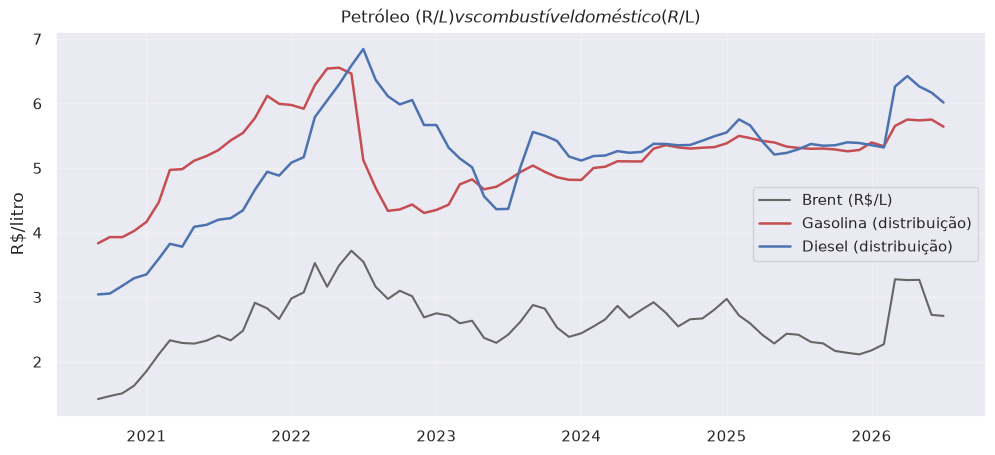

In [7]:
# Visualiza o insumo (Brent em R$/L) contra os preços domésticos na mesma unidade.
fig, ax = plt.subplots()
ax.plot(df.index, df["Brent_L"], label="Brent (R$/L)", color="0.4", lw=1.5)
ax.plot(df.index, df["gasolina"], label="Gasolina (distribuição)", color="C3", lw=1.8)
ax.plot(df.index, df["diesel"], label="Diesel (distribuição)", color="C0", lw=1.8)
ax.set_title("Petróleo (R$/L) vs combustível doméstico (R$/L)")
ax.set_ylabel("R$/litro")
ax.legend()
plt.show()


#### **Camada B — Paridade de importação e gap**

**Definição.** `gap = PPI + tributos − preço doméstico`. Gap positivo = Petrobras vende abaixo da
paridade de importação (deixa dinheiro na mesa).

**Base de comparação.** O `PPI` é o custo de importação (derivado internacional × câmbio + custo),
**sem tributos**; o preço ANP é de distribuição, **com ICMS/PIS/COFINS/CIDE e margem**. Somamos os
tributos ao PPI para comparar na mesma base (valores em `TRIBUTOS`: LC 192/2022, MPV 1.157/1.163 e
Convênios ICMS/Confaz).

**Ressalva.** O gap ainda **subestima** a perda porque o preço doméstico inclui a mistura de
etanol/biodiesel e a margem da distribuidora.


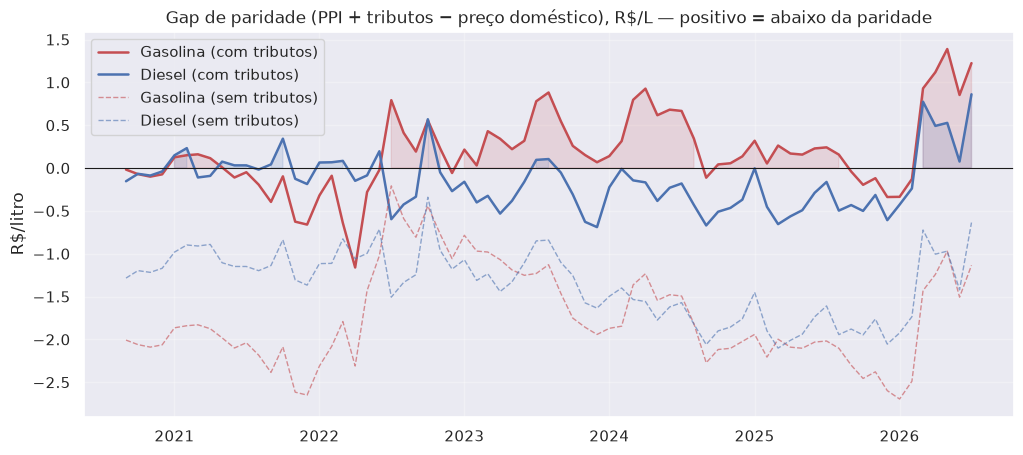

In [8]:
# Gap de paridade nas duas bases: com e sem tributos (a versão sem tributos é referência).
df["gap_gasolina"] = df["PPI_gasolina_trib"] - df["gasolina"]
df["gap_diesel"]   = df["PPI_diesel_trib"] - df["diesel"]
df["gap_gasolina_sem_trib"] = df["PPI_gasolina"] - df["gasolina"]
df["gap_diesel_sem_trib"]   = df["PPI_diesel"] - df["diesel"]

# Série temporal dos gaps; linhas sólidas = com tributos, tracejadas = sem tributos.
fig, ax = plt.subplots()
ax.plot(df.index, df["gap_gasolina"], label="Gasolina (com tributos)", color="C3", lw=1.8)
ax.plot(df.index, df["gap_diesel"], label="Diesel (com tributos)", color="C0", lw=1.8)
ax.plot(df.index, df["gap_gasolina_sem_trib"], label="Gasolina (sem tributos)", color="C3", lw=1.0, ls="--", alpha=0.6)
ax.plot(df.index, df["gap_diesel_sem_trib"], label="Diesel (sem tributos)", color="C0", lw=1.0, ls="--", alpha=0.6)
ax.axhline(0, color="k", lw=0.8)  # zero = exatamente na paridade
# Sombreia apenas os períodos de gap positivo (abaixo da paridade).
ax.fill_between(df.index, 0, df["gap_gasolina"], where=df["gap_gasolina"] > 0, color="C3", alpha=0.15)
ax.fill_between(df.index, 0, df["gap_diesel"], where=df["gap_diesel"] > 0, color="C0", alpha=0.15)
ax.set_title("Gap de paridade (PPI + tributos − preço doméstico), R$/L — positivo = abaixo da paridade")
ax.set_ylabel("R$/litro")
ax.legend()
plt.show()


#### **Sangria estimada = gap × volume**

**Objetivo.** Monetizar o gap: quanto a Petrobras deixou de arrecadar ao vender abaixo da
paridade. `sangria = max(gap, 0) × volume vendido`.

**Por que `clip(lower=0)`.** Só contamos gaps positivos; quando o preço doméstico está acima da
paridade, não há "perda" a estimar (e não descontamos ganho, para manter a estimativa
conservadora).

**Unidade.** Resultado em R$ bilhões/mês.

#### **Incerteza da sangria**

**Por que não um número único.** A sangria depende de três premissas frágeis: o custo de
importação (fixo em R$ 0,15/L), a tabela de tributos (curada à mão) e o uso de proxies
(`RB=F`/`HO=F`) no lugar da referência real de importação. O resultado varia muito com elas.

**Como tratamos.** (1) Uma **tabela de cenários** variando uma premissa por vez; (2) um **Monte
Carlo** (~2.000 simulações, seed fixo) variando as três simultaneamente, reportando a faixa
p5–p95. O **cenário base** (premissas atuais) é mantido como referência.

O cenário **"sem tributos"** aparece na tabela apenas como **referência de base incompatível** (compara PPI sem imposto com preço doméstico com imposto) e **não** entra no Monte Carlo: a incerteza legítima sobre tributos é a acurácia da tabela, não a existência deles.


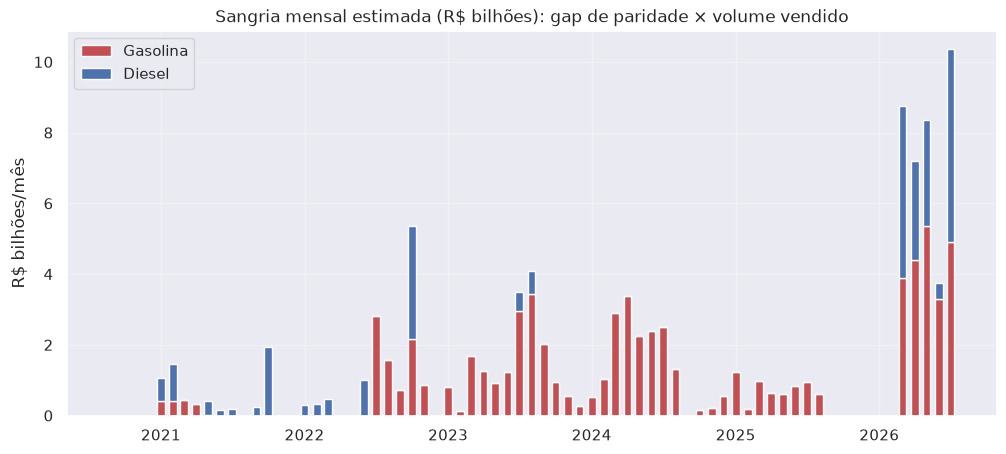

Sangria acumulada no período: R$ 98.7 bilhões
  gasolina: R$ 71.0 bi
  diesel:   R$ 27.6 bi


In [9]:
# Monetiza o gap positivo (clip em 0) pelo volume mensal vendido (litros).
df["sangria_gasolina"] = df["gap_gasolina"].clip(lower=0) * df["gasolina_L"]
df["sangria_diesel"]   = df["gap_diesel"].clip(lower=0) * df["diesel_L"]
df["sangria_total"] = df["sangria_gasolina"] + df["sangria_diesel"]

# Barras empilhadas: gasolina na base, diesel por cima; converte R$ -> R$ bilhões.
fig, ax = plt.subplots()
ax.bar(df.index, df["sangria_gasolina"] / 1e9, width=20, label="Gasolina", color="C3")
ax.bar(df.index, df["sangria_diesel"] / 1e9, width=20, bottom=df["sangria_gasolina"] / 1e9,
       label="Diesel", color="C0")
ax.set_title("Sangria mensal estimada (R$ bilhões): gap de paridade × volume vendido")
ax.set_ylabel("R$ bilhões/mês")
ax.legend()
plt.show()

print(f"Sangria acumulada no período: R$ {df['sangria_total'].sum()/1e9:,.1f} bilhões")
print(f"  gasolina: R$ {df['sangria_gasolina'].sum()/1e9:,.1f} bi")
print(f"  diesel:   R$ {df['sangria_diesel'].sum()/1e9:,.1f} bi")


Sangria acumulada por cenário (R$ bilhões):
                                        gasolina (R$ bi)  diesel (R$ bi)  \
Base                                                71.0            27.6   
Sem tributos (ref., base incompatível)               0.0             0.0   
Custo baixo (0,05)                                  55.3            19.1   
Custo alto (0,35)                                  111.2            58.8   
Proxy -10%                                          26.9             3.8   
Proxy +10%                                         140.7           101.2   
Tributos -20%                                       27.2            11.8   
Tributos +20%                                      154.7            66.7   

                                        total (R$ bi)  
Base                                             98.7  
Sem tributos (ref., base incompatível)            0.0  
Custo baixo (0,05)                               74.3  
Custo alto (0,35)                              

Sangria acumulada (Monte Carlo, 2000 simulações):
  mediana = R$ 113.2 bi | faixa (p5-p95) = R$ 28.6 a R$ 295.1 bi
  mínimo = R$ 12.7 bi | máximo = R$ 415.8 bi


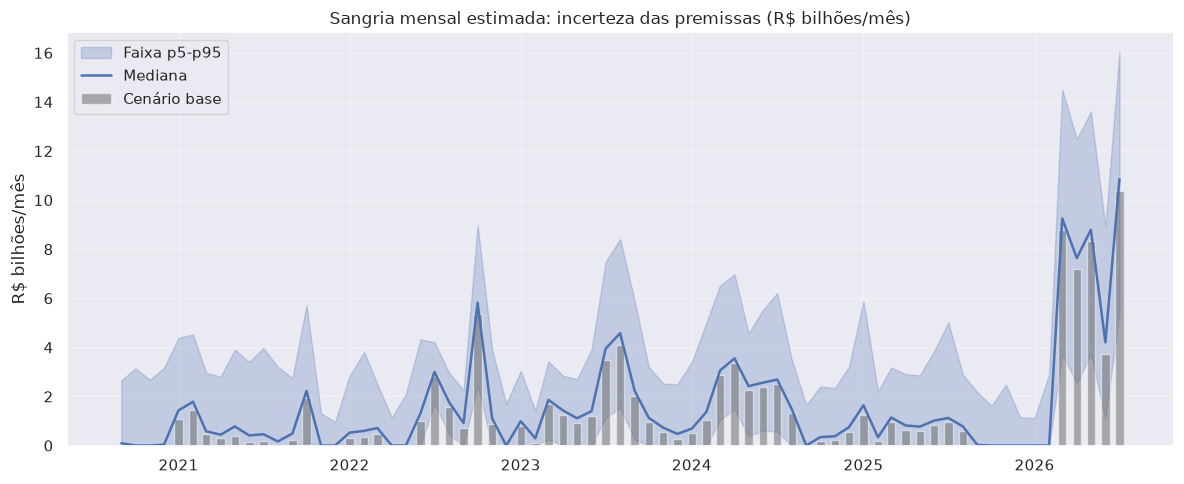

In [10]:
# --- P0.2: banda de incerteza da sangria (sensibilidade das premissas) ---
# A sangria depende de premissas frágeis: custo de importação, tabela de tributos e
# o uso de proxies (RBOB/ULSD). Variamos essas fontes de incerteza em vez de fixar valores.


def gap_mensal(custo_import, tax_mult, proxy_markup):
    """Gap de paridade (R$/L) para gasolina e diesel sob um conjunto de premissas."""
    # PPI: proxy internacional escalado (proxy_markup) + custo de importação variável.
    ppi_g = df["RB=F"] / GAL * df["BRL=X"] * proxy_markup + custo_import
    ppi_d = df["HO=F"] / GAL * df["BRL=X"] * proxy_markup + custo_import
    # Tributos escalados por tax_mult (0 = cenário sem tributos).
    gap_g = (ppi_g + tax_mult * df["trib_gasolina"]) - df["gasolina"]
    gap_d = (ppi_d + tax_mult * df["trib_diesel"]) - df["diesel"]
    return gap_g, gap_d


def sangria_de(gap_g, gap_d):
    """Monetiza os gaps positivos pelo volume vendido (R$)."""
    return gap_g.clip(lower=0) * df["gasolina_L"] + gap_d.clip(lower=0) * df["diesel_L"]


# --- (1) Tabela de cenários: varia uma premissa por vez, mantendo as demais na base ---
base = dict(custo_import=CUSTO_IMPORT, tax_mult=1.0, proxy_markup=1.0)
cenarios = {
    "Base": base,
    "Sem tributos (ref., base incompatível)": {**base, "tax_mult": 0.0},
    "Custo baixo (0,05)": {**base, "custo_import": 0.05},
    "Custo alto (0,35)": {**base, "custo_import": 0.35},
    "Proxy -10%": {**base, "proxy_markup": 0.90},
    "Proxy +10%": {**base, "proxy_markup": 1.10},
    "Tributos -20%": {**base, "tax_mult": 0.80},
    "Tributos +20%": {**base, "tax_mult": 1.20},
}


def acumulado(c):
    gg, gd = gap_mensal(**c)
    sg = (gg.clip(lower=0) * df["gasolina_L"]).sum() / 1e9
    sd = (gd.clip(lower=0) * df["diesel_L"]).sum() / 1e9
    return pd.Series({"gasolina (R$ bi)": sg, "diesel (R$ bi)": sd, "total (R$ bi)": sg + sd})


tab_cenarios = pd.DataFrame({k: acumulado(v) for k, v in cenarios.items()}).T
print("Sangria acumulada por cenário (R$ bilhões):")
print(tab_cenarios.round(1))

# --- (2) Monte Carlo: incerteza conjunta das premissas -> faixa (p5-p95) ---
rng = np.random.default_rng(42)
N = 2000
sang_mensal = np.empty((N, len(df)))
for i in range(N):
    gg, gd = gap_mensal(
        custo_import=rng.uniform(0.05, 0.35),
        tax_mult=rng.choice([0.8, 1.0, 1.2], p=[0.25, 0.50, 0.25]),
        proxy_markup=rng.uniform(0.95, 1.05),
    )
    sang_mensal[i] = sangria_de(gg, gd).values

sang_acum = sang_mensal.sum(axis=1) / 1e9
p5, p50, p95 = np.percentile(sang_acum, [5, 50, 95])
print(f"Sangria acumulada (Monte Carlo, {N} simulações):")
print(f"  mediana = R$ {p50:,.1f} bi | faixa (p5-p95) = R$ {p5:,.1f} a R$ {p95:,.1f} bi")
print(f"  mínimo = R$ {sang_acum.min():,.1f} bi | máximo = R$ {sang_acum.max():,.1f} bi")

# Fan chart: percentis mensais da sangria ao longo do tempo.
faixa_mensal = np.percentile(sang_mensal / 1e9, [5, 50, 95], axis=0)
fig, ax = plt.subplots()
ax.fill_between(df.index, faixa_mensal[0], faixa_mensal[2],
                color="C0", alpha=0.25, label="Faixa p5-p95")
ax.plot(df.index, faixa_mensal[1], color="C0", lw=1.8, label="Mediana")
ax.bar(df.index, df["sangria_total"] / 1e9, width=18, color="0.4", alpha=0.5, label="Cenário base")
ax.set_title("Sangria mensal estimada: incerteza das premissas (R$ bilhões/mês)")
ax.set_ylabel("R$ bilhões/mês")
ax.legend()
plt.tight_layout()
plt.savefig("images/02_sensibilidade.png", dpi=120)
plt.show()


#### **Leitura da faixa**

A faixa é movida principalmente pelo **custo de importação** e pela **acurácia da tabela de tributos**; o proxy internacional tem efeito menor. O cenário "sem tributos" (gap estruturalmente negativo, por incompatibilidade de base) fica **fora** da faixa. O resultado deve ser lido como **ordem de grandeza**, e a sensibilidade indica quais premissas mereceriam dados melhores (custo de importação real e tributos efetivos por estado).


#### **Resumo**

**Objetivo.** Consolidar período, repasse acumulado (Camada A), tributos médios, gaps médios
(com/sem tributos) e sangria estimada, inclusive por ano.


In [11]:
# Bloco de resumo: período, repasse (com inferência), tributos, gaps e sangria.
print(f"Período: {df.index.min().date()} a {df.index.max().date()} ({len(df)} meses)")
print()
for nome in ["gasolina", "diesel"]:
    modelo, _ = modelos[nome]
    b0 = float(modelo.params["b0"])
    # Repasse acumulado Σβₖ e erro-padrão HAC via combinação linear (t_test).
    teste = modelo.t_test(" + ".join([f"b{k}" for k in range(4)]) + " = 0")
    rep = float(np.ravel(teste.effect)[0])
    se = float(np.ravel(teste.sd)[0])
    print(f"{nome}: repasse acumulado 0-3m = {rep:.2f} (erro-padrão {se:.2f}, "
          f"p {teste.pvalue:.3f}; contemporâneo {b0:.2f}, R2_aj {modelo.rsquared_adj:.2f})")
print()
print(f"Tributo médio somado ao PPI — gasolina: R$ {df['trib_gasolina'].mean():.2f}/L "
      f"| diesel: R$ {df['trib_diesel'].mean():.2f}/L")
print(f"Gap médio (com tributos) gasolina: R$ {df['gap_gasolina'].mean():.2f}/L "
      f"| diesel: R$ {df['gap_diesel'].mean():.2f}/L")
print(f"Gap médio (sem tributos) gasolina: R$ {df['gap_gasolina_sem_trib'].mean():.2f}/L "
      f"| diesel: R$ {df['gap_diesel_sem_trib'].mean():.2f}/L")
print(f"Sangria estimada acumulada (cenário base): R$ {df['sangria_total'].sum()/1e9:,.1f} bilhões")
print(f"  gasolina: R$ {df['sangria_gasolina'].sum()/1e9:,.1f} bi | diesel: R$ {df['sangria_diesel'].sum()/1e9:,.1f} bi")
print(f"  faixa (Monte Carlo p5-p95): R$ {p5:,.1f} a R$ {p95:,.1f} bi (mediana R$ {p50:,.1f} bi)")
# Agrega a sangria por ano para destacar a concentração temporal.
por_ano = df.groupby(df.index.year)["sangria_total"].sum() / 1e9
print("  por ano (R$ bi): " + " | ".join(f"{a}: {v:.0f}" for a, v in por_ano.items()))
print()
print("Ressalvas: preço de distribuição inclui mistura de etanol/biodiesel e margem da distribuidora;")
print("RB=F/HO=F são proxies dos derivados; alíquotas de ICMS pré-2023 (ad valorem) são aproximadas.")


Período: 2020-09-01 a 2026-07-01 (71 meses)

gasolina: repasse acumulado 0-3m = 0.33 (erro-padrão 0.11, p 0.002; contemporâneo 0.20, R2_aj 0.16)
diesel: repasse acumulado 0-3m = 0.62 (erro-padrão 0.09, p 0.000; contemporâneo 0.36, R2_aj 0.56)

Tributo médio somado ao PPI — gasolina: R$ 1.91/L | diesel: R$ 1.20/L
Gap médio (com tributos) gasolina: R$ 0.18/L | diesel: R$ -0.16/L
Gap médio (sem tributos) gasolina: R$ -1.73/L | diesel: R$ -1.35/L
Sangria estimada acumulada (cenário base): R$ 98.7 bilhões
  gasolina: R$ 71.0 bi | diesel: R$ 27.6 bi
  faixa (Monte Carlo p5-p95): R$ 28.6 a R$ 295.1 bi (mediana R$ 113.2 bi)
  por ano (R$ bi): 2020: 0 | 2021: 6 | 2022: 13 | 2023: 17 | 2024: 17 | 2025: 6 | 2026: 38

Ressalvas: preço de distribuição inclui mistura de etanol/biodiesel e margem da distribuidora;
RB=F/HO=F são proxies dos derivados; alíquotas de ICMS pré-2023 (ad valorem) são aproximadas.


#### **Conclusão**

**Sim — houve represamento de preço via Petrobras, mas intermitente e concentrado na gasolina.**

As três camadas convergem:

1. **Mercado (Fase 1).** Beta da PETR4 ao Brent = 0,39 vs PRIO3 0,60: a empresa integrada reage
   menos ao petróleo que a produtora pura, consistente com interferência no repasse.
2. **Repasse (Camada A).** Acumulado 0-3m: gasolina 0,33 vs diesel 0,62. A gasolina repassa cerca
   de metade do diesel — sinal mais forte justamente no combustível politicamente sensível. Parte
   da diferença, porém, vem da mistura de etanol (27%), que amortece o Brent.
3. **Paridade (Camada B).** Na média do período o gap com tributos fica perto de zero (gasolina
   +0,18, diesel -0,16 R$/L), ou seja, *não* houve represamento contínuo. A sangria estimada
   (cenário base R$ 98,7 bi; faixa de sensibilidade R$ 28,6–295,1 bi, mediana R$ 113,2 bi)
   concentra-se em janelas: 2023-24 (~R$ 17 bi/ano) e sobretudo 2026 (R$ 38 bi em
   7 meses, gap da gasolina ~+1,2 R$/L). O diesel ficou próximo/igual à paridade.

**Leitura.** O preço da gasolina foi mantido abaixo da paridade de importação em janelas
específicas (2021-22 e 2026), enquanto o diesel seguiu mais de perto a paridade — padrão coerente
com uso seletivo do preço da gasolina como instrumento anti-inflacionário.

**Ressalvas.** O valor da sangria é muito sensível a hipóteses: proxy RBOB/ULSD (`RB=F`/`HO=F`)
em vez da referência real de importação, custo de importação fixo (R$ 0,15, provavelmente
subestimado), alíquotas de ICMS pré-2023 (ad valorem, aproximadas) e o fato de o preço ANP ser de
distribuição (inclui etanol/biodiesel e margem). Gap ≠ decisão política: pode refletir defasagem
da política de preços e prêmios de importação. Trate o número como ordem de grandeza, não como
valor exato. Para robustez: isolar etanol, rodar repasse por sub-período, sensibilidade do
`CUSTO_IMPORT` e teste de placebo com combustível não controlado.


#### **Reprodutibilidade e próximos passos**

**Ambiente.** Dependências declaradas em `pyproject.toml` (`yfinance`, `pandas`, `numpy`,
`requests`, `matplotlib`, `seaborn`, `openpyxl`).

**Reprodução.** Executar as células em ordem; as fontes da ANP e do Yahoo Finance são baixadas em
tempo de execução e podem sofrer revisões retroativas.

**Próximos passos.**
- Rodar a Camada A por sub-período (pré/pós mudança de política de preços).
- Sensibilidade de `CUSTO_IMPORT` (R$ 0,10–0,30/L) e do defasamento (`lags`).
- Substituir os proxies RBOB/ULSD por referências reais de importação.
- Teste de placebo com combustível não controlado e isolamento do etanol/biodiesel.
